# Pipeline de Modelagem v2 — Boosting e Melhoria de Features

Este notebook implementa uma segunda rodada de modelagem preditiva para prever o número diário de internações por doenças respiratórias no Rio de Janeiro (D0), buscando superar os resultados obtidos com Random Forest na versão anterior.

**Motivação:** O modelo RF anterior alcançou MAE=50.82 e R²=0.59 no teste, mas apresentou subestimação sistemática dos picos e alta redundância entre features endógenas. Esta versão foca em:
- Reduzir redundância entre features via seleção e novas features;
- Testar modelos de boosting (HistGBR, XGBoost, LightGBM);
- Melhorar a captura dos picos respiratórios;
- Explorar melhor as variáveis atmosféricas.

**Benchmark RF anterior (teste):**

| Métrica | RF Final |
|---------|----------|
| MAE     | 50.82    |
| RMSE    | 68.85    |
| R²      | 0.5877   |
| sMAPE   | 19.76%   |

**Etapas:**
1. Carregamento e preparação
2. Reprodução dos baselines e benchmark RF
3. Engenharia de features secundárias
4. Seleção de features
5. Comparação de modelos (RF, HistGBR, XGBoost, LightGBM)
6. Estratégias para picos
7. Ajuste de hiperparâmetros
8. Avaliação final e diagnósticos
9. Interpretabilidade
10. Consolidação e salvamento

## 1. Imports e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

BASE_DIR = Path('../../Data')
OUTPUT_DIR = BASE_DIR / 'GoldData' / 'ModelResults_v2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Setup concluído.')
print(f'xgboost: {xgb.__version__}')
print(f'lightgbm: {lgb.__version__}')

Setup concluído.
xgboost: 3.2.0
lightgbm: 4.6.0


## 2. Carregamento, Inspeção e Preparação

In [2]:
PATH_DATASET = BASE_DIR / 'GoldData' / 'modelDataset.parquet'
df = pd.read_parquet(PATH_DATASET)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Período: {df["data"].min().date()} a {df["data"].max().date()}')
print(f'NaN total: {df.isnull().sum().sum()}')
print(f'\nEstatísticas do alvo:')
print(df['target'].describe().round(2))

Shape: (2192, 31)
Período: 2012-12-31 a 2018-12-31
NaN total: 0

Estatísticas do alvo:
count    2192.00
mean      339.82
std       159.18
min        48.00
25%       220.00
50%       315.00
75%       429.00
max      1079.00
Name: target, dtype: float64


## 3. Divisão Temporal

Mesma divisão da rodada anterior para garantir comparabilidade:
- **Treino:** até 2016-12-31
- **Validação:** 2017
- **Teste:** 2018

In [3]:
TARGET_COL = 'target'
NON_FEATURE_COLS = ['data', 'target']

# Features originais (29 do notebook anterior)
original_feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]

dates = df['data']

TRAIN_END = pd.Timestamp('2016-12-31')
VAL_END = pd.Timestamp('2017-12-31')

mask_train = dates <= TRAIN_END
mask_val = (dates > TRAIN_END) & (dates <= VAL_END)
mask_test = dates > VAL_END

print('Divisão temporal:')
for name, mask in [('Treino', mask_train), ('Validação', mask_val), ('Teste', mask_test)]:
    d = dates[mask]
    print(f'  {name}: {d.min().date()} a {d.max().date()} '
          f'({mask.sum()} dias, {mask.sum()/len(df)*100:.1f}%)')

Divisão temporal:
  Treino: 2012-12-31 a 2016-12-31 (1462 dias, 66.7%)
  Validação: 2017-01-01 a 2017-12-31 (365 dias, 16.7%)
  Teste: 2018-01-01 a 2018-12-31 (365 dias, 16.7%)


## 4. Funções Auxiliares

In [15]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    denominator = np.where(denominator == 0, 1, denominator)
    return np.mean(np.abs(y_true - y_pred) / denominator) * 100


def evaluate(y_true, y_pred, label='', verbose=True):
    """Calcula e retorna métricas de regressão."""
    metrics = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred)
    }
    if verbose and label:
        print(f'\n--- {label} ---')
        for k, v in metrics.items():
            print(f'  {k}: {v:.4f}')
    return metrics


def evaluate_peak(y_true, y_pred, dates_series, label=''):
    """Avalia métricas separadas para período de pico (abr-jul) e fora de pico."""
    months = pd.to_datetime(dates_series).month
    mask_peak = np.isin(months, [4, 5, 6, 7])
    mask_normal = ~mask_peak

    results = {}
    for name, m in [('Pico (abr-jul)', mask_peak), ('Fora de pico', mask_normal)]:
        if m.sum() > 0:
            results[name] = evaluate(y_true[m], y_pred[m], verbose=False)
    
    if label:
        print(f'\n--- {label} ---')
        df_peak = pd.DataFrame(results).T
        display(df_peak.round(4))
    return results


print('Funções auxiliares definidas.')

Funções auxiliares definidas.


## 5. Reprodução dos Baselines e Benchmark RF

Antes de propor melhorias, reproduzimos os baselines e o Random Forest com `log1p` para confirmar os resultados e estabelecer o benchmark interno.

In [5]:
X_orig = df[original_feature_cols].copy()
y = df[TARGET_COL].copy()

X_train_orig = X_orig[mask_train]
X_val_orig = X_orig[mask_val]
X_test_orig = X_orig[mask_test]

y_train = y[mask_train].values.astype(float)
y_val = y[mask_val].values.astype(float)
y_test = y[mask_test].values.astype(float)

dates_train = dates[mask_train]
dates_val = dates[mask_val]
dates_test = dates[mask_test]

# Alvo transformado
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# --- Baselines ---
print('=== Baselines (Validação) ===')
baselines_val = {}
baselines_val['Persistência (lag_1)'] = evaluate(
    y_val, X_val_orig['lag_1'].values, 'Persistência (lag_1)')
baselines_val['Média Móvel 7d'] = evaluate(
    y_val, X_val_orig['rolling_mean_7'].values, 'Média Móvel 7d')
baselines_val['Lag 7'] = evaluate(
    y_val, X_val_orig['lag_7'].values, 'Lag 7')

print('\n=== Baselines (Teste) ===')
baselines_test = {}
baselines_test['Persistência (lag_1)'] = evaluate(
    y_test, X_test_orig['lag_1'].values, 'Persistência (lag_1)')
baselines_test['Média Móvel 7d'] = evaluate(
    y_test, X_test_orig['rolling_mean_7'].values, 'Média Móvel 7d')
baselines_test['Lag 7'] = evaluate(
    y_test, X_test_orig['lag_7'].values, 'Lag 7')

# --- RF Benchmark (log1p, hiperparâmetros da rodada anterior) ---
print('\n=== RF Benchmark (hiperparâmetros da rodada anterior) ===')
rf_bench_params = dict(
    n_estimators=459, max_depth=40, max_features=0.7,
    min_samples_leaf=3, min_samples_split=13, random_state=SEED, n_jobs=-1
)
pipe_rf_bench = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestRegressor(**rf_bench_params))
])

# Treina com treino+val (como no notebook anterior)
X_trainval_orig = pd.concat([X_train_orig, X_val_orig])
y_trainval_log = np.concatenate([y_train_log, y_val_log])

pipe_rf_bench.fit(X_trainval_orig, y_trainval_log)
pred_test_rf_bench = np.expm1(pipe_rf_bench.predict(X_test_orig))
pred_test_rf_bench = np.maximum(pred_test_rf_bench, 0)

metrics_rf_bench = evaluate(y_test, pred_test_rf_bench, 'RF Benchmark (Teste)')

# Tabela consolidada
df_bench = pd.DataFrame(baselines_test).T
df_bench.loc['RF Benchmark (v1)'] = metrics_rf_bench
print('\n=== Benchmark Consolidado — Teste ===')
display(df_bench.round(4))

=== Baselines (Validação) ===

--- Persistência (lag_1) ---
  MAE: 73.7178
  RMSE: 93.1991
  R²: -0.0300
  sMAPE: 31.7041

--- Média Móvel 7d ---
  MAE: 57.0978
  RMSE: 71.3484
  R²: 0.3964
  sMAPE: 25.0142

--- Lag 7 ---
  MAE: 61.6712
  RMSE: 78.0145
  R²: 0.2783
  sMAPE: 27.1481

=== Baselines (Teste) ===

--- Persistência (lag_1) ---
  MAE: 73.8822
  RMSE: 100.6483
  R²: 0.1190
  sMAPE: 28.6169

--- Média Móvel 7d ---
  MAE: 61.1832
  RMSE: 78.3404
  R²: 0.4662
  sMAPE: 24.1380

--- Lag 7 ---
  MAE: 67.8849
  RMSE: 90.8666
  R²: 0.2819
  sMAPE: 26.8286

=== RF Benchmark (hiperparâmetros da rodada anterior) ===

--- RF Benchmark (Teste) ---
  MAE: 50.8204
  RMSE: 68.8494
  R²: 0.5877
  sMAPE: 19.7561

=== Benchmark Consolidado — Teste ===


,MAE,RMSE,R²,sMAPE
Persistência (lag_1),73.8822,100.6483,0.1190,28.6169
Média Móvel 7d,61.1832,78.3404,0.4662,24.1380
Lag 7,67.8849,90.8666,0.2819,26.8286
RF Benchmark (v1),50.8204,68.8494,0.5877,19.7561


## 6. Engenharia de Features Secundárias

Novas features conforme `featureDefinition.md` (features secundárias que não foram exploradas na v1):

**Série de internações:**
- Diferenças: `diff_1`, `diff_7`, `diff_30`
- Rolling sum: `rolling_sum_7`, `rolling_sum_14`, `rolling_sum_30`
- Rolling min/max: `rolling_min_7`, `rolling_max_7`
- Dummies de regime temporal: `bloco_2012_2013`, `bloco_2014_2015`, `bloco_2016_2018`
- Dummies de extremos
- Componentes cíclicos: `sin_ano`, `cos_ano`

**Atmosféricas secundárias:**
- `pm10_ma_30d_shift_1d`
- Interações simples entre variáveis atmosféricas

In [6]:
# Recarrega os dados brutos para criar features adicionais sobre a série completa
# (precisamos das colunas originais de internações e atmosféricas)
PATH_INTERNACOES = BASE_DIR / 'IntermediaryData' / 'DataSus' / 'respiratory_hospitalization_time_series.parquet'
PATH_QUALIAR = BASE_DIR / 'IntermediaryData' / 'MonitorAr' / 'DailyQualiarRj' / 'serie_diaria_qualidade_ar_rio_de_janeiro.parquet'

df_int = pd.read_parquet(PATH_INTERNACOES)
df_qa = pd.read_parquet(PATH_QUALIAR)

df_int['data'] = pd.to_datetime(df_int['data_dia']).dt.normalize()
df_qa['data'] = pd.to_datetime(df_qa['data']).dt.normalize()

df_raw = pd.merge(
    df_int[['data', 'num_internacoes']],
    df_qa,
    on='data', how='inner'
).sort_values('data').reset_index(drop=True)

# Interpola NaN nas atmosféricas (mesmo tratamento da v1)
vars_atm = ['no', 'no2', 'so2', 'pm2_5', 'nox', 'ur', 'temp', 'o3', 'co', 'pm10']
df_raw[vars_atm] = df_raw[vars_atm].interpolate(method='linear', limit_direction='both')

print(f'Dados brutos: {df_raw.shape}')
print(f'Período: {df_raw["data"].min().date()} a {df_raw["data"].max().date()}')

Dados brutos: (2557, 13)
Período: 2012-01-01 a 2018-12-31


In [7]:
serie = df_raw['num_internacoes']
serie_shifted = serie.shift(1)

# --- Diferenças (baseadas em shift(1) para evitar leakage D0) ---
# diff_k = y[t-1] - y[t-1-k]  (variação dos últimos k dias até ontem)
df_raw['diff_1'] = serie_shifted - serie.shift(2)
df_raw['diff_7'] = serie_shifted - serie.shift(8)
df_raw['diff_30'] = serie_shifted - serie.shift(31)

# --- Rolling sums (shift 1 para evitar leakage D0) ---
for w in [7, 14, 30]:
    df_raw[f'rolling_sum_{w}'] = serie_shifted.rolling(w).sum()

# --- Rolling min/max ---
df_raw['rolling_min_7'] = serie_shifted.rolling(7).min()
df_raw['rolling_max_7'] = serie_shifted.rolling(7).max()

# --- Dummies de regime temporal ---
year = df_raw['data'].dt.year
df_raw['bloco_2012_2013'] = year.isin([2012, 2013]).astype(int)
df_raw['bloco_2014_2015'] = year.isin([2014, 2015]).astype(int)
df_raw['bloco_2016_2018'] = year.isin([2016, 2017, 2018]).astype(int)

# --- Dummies de extremos (baseadas no treino) ---
# Calcula percentis apenas no período de treino para evitar leakage
mask_train_raw = df_raw['data'] <= TRAIN_END
p95_train = serie[mask_train_raw].quantile(0.95)
p05_train = serie[mask_train_raw].quantile(0.05)
# Usa lag_1 para não olhar o valor do próprio dia
df_raw['dummy_extremo_positivo'] = (serie.shift(1) > p95_train).astype(int)
df_raw['dummy_extremo_negativo'] = (serie.shift(1) < p05_train).astype(int)

# --- Componentes cíclicos anuais ---
day_of_year = df_raw['data'].dt.dayofyear
df_raw['sin_ano'] = np.sin(2 * np.pi * day_of_year / 365.25)
df_raw['cos_ano'] = np.cos(2 * np.pi * day_of_year / 365.25)

# --- PM10 (feature atmosférica secundária) ---
df_raw['pm10_ma_30d_shift_1d'] = df_raw['pm10'].shift(1).rolling(30).mean()

# --- Interações atmosféricas simples ---
# Produto temperatura × umidade (condição frio+úmido favorece doenças respiratórias)
df_raw['temp_x_ur'] = df_raw['temp'].shift(1).rolling(14).mean() * df_raw['ur'].shift(1).rolling(14).mean()
# Razão NO/NO2 (proxy para fotoquímica)
df_raw['no_no2_ratio'] = (df_raw['no'].shift(1).rolling(7).mean() /
                           df_raw['no2'].shift(1).rolling(7).mean().replace(0, np.nan))

new_features = [
    'diff_1', 'diff_7', 'diff_30',
    'rolling_sum_7', 'rolling_sum_14', 'rolling_sum_30',
    'rolling_min_7', 'rolling_max_7',
    'bloco_2012_2013', 'bloco_2014_2015', 'bloco_2016_2018',
    'dummy_extremo_positivo', 'dummy_extremo_negativo',
    'sin_ano', 'cos_ano',
    'pm10_ma_30d_shift_1d',
    'temp_x_ur', 'no_no2_ratio',
]

print(f'Novas features criadas ({len(new_features)}):')
for f in new_features:
    print(f'  {f}: NaN={df_raw[f].isnull().sum()}')

Novas features criadas (18):
  diff_1: NaN=2
  diff_7: NaN=8
  diff_30: NaN=31
  rolling_sum_7: NaN=7
  rolling_sum_14: NaN=14
  rolling_sum_30: NaN=30
  rolling_min_7: NaN=7
  rolling_max_7: NaN=7
  bloco_2012_2013: NaN=0
  bloco_2014_2015: NaN=0
  bloco_2016_2018: NaN=0
  dummy_extremo_positivo: NaN=0
  dummy_extremo_negativo: NaN=0
  sin_ano: NaN=0
  cos_ano: NaN=0
  pm10_ma_30d_shift_1d: NaN=30
  temp_x_ur: NaN=14
  no_no2_ratio: NaN=7


In [8]:
# Faz merge das novas features no dataset de modelagem via data
df_new = df_raw[['data'] + new_features].copy()
df_ext = df.merge(df_new, on='data', how='left')

# Features estendidas = originais + novas
extended_feature_cols = original_feature_cols + new_features

# Remove linhas com NaN nas novas features
n_before = len(df_ext)
df_ext = df_ext.dropna(subset=extended_feature_cols).reset_index(drop=True)
n_after = len(df_ext)
print(f'Linhas: {n_before} → {n_after} (removidas: {n_before - n_after})')
print(f'Período: {df_ext["data"].min().date()} a {df_ext["data"].max().date()}')
print(f'Total de features: {len(extended_feature_cols)}')

# Atualiza masks para o dataset estendido
dates_ext = df_ext['data']
mask_train_ext = dates_ext <= TRAIN_END
mask_val_ext = (dates_ext > TRAIN_END) & (dates_ext <= VAL_END)
mask_test_ext = dates_ext > VAL_END

X_ext = df_ext[extended_feature_cols].copy()
y_ext = df_ext[TARGET_COL].values.astype(float)

X_train_ext = X_ext[mask_train_ext]
X_val_ext = X_ext[mask_val_ext]
X_test_ext = X_ext[mask_test_ext]

y_train_ext = y_ext[mask_train_ext.values]
y_val_ext = y_ext[mask_val_ext.values]
y_test_ext = y_ext[mask_test_ext.values]

dates_train_ext = dates_ext[mask_train_ext]
dates_val_ext = dates_ext[mask_val_ext]
dates_test_ext = dates_ext[mask_test_ext]

y_train_ext_log = np.log1p(y_train_ext)
y_val_ext_log = np.log1p(y_val_ext)
y_test_ext_log = np.log1p(y_test_ext)

print(f'\nTreino: {mask_train_ext.sum()}, Val: {mask_val_ext.sum()}, Teste: {mask_test_ext.sum()}')

Linhas: 2192 → 2192 (removidas: 0)
Período: 2012-12-31 a 2018-12-31
Total de features: 47

Treino: 1462, Val: 365, Teste: 365


## 7. Seleção de Features — Redução de Redundância

A v1 mostrou que lags e médias móveis são altamente correlacionados entre si. Definimos conjuntos de features para testar:

| Conjunto | Descrição |
|----------|----------|
| **A — Original (29)** | Mesmo conjunto da v1 |
| **B — Reduzido (seleção)** | Remove lags e rolling redundantes, mantém os mais informativos |
| **C — Estendido (47)** | Original + features secundárias |
| **D — Estendido Reduzido** | Seleção do conjunto estendido |

In [9]:
# Conjunto A — Original (29 features da v1)
features_A = original_feature_cols.copy()

# Conjunto B — Reduzido: remove redundâncias entre lags e rollings
# Mantém: lag_1 (curto prazo), lag_7 (semanal, mais importante por MDI),
#          lag_365 (anual), rolling_mean_7 (nível recente, top 2 MDI),
#          rolling_std_7 (volatilidade), e todas as atmosféricas e calendário
features_B = [
    # Lags reduzidos (3 de 9)
    'lag_1', 'lag_7', 'lag_365',
    # Rolling reduzidos (2 de 5)
    'rolling_mean_7', 'rolling_std_7',
    # Calendário (todos)
    'dia_semana', 'fim_de_semana', 'mes', 'semana_epidemiologica',
    'estacao', 'dummy_periodo_pico_sazonal',
    # Atmosféricas (todas)
    'o3_ma_120d_shift_1d', 'no_ma_30d_shift_1d', 'co_ma_120d_shift_1d',
    'so2_ma_150d_shift_21d', 'nox_ma_21d_shift_1d', 'no2_lag0',
    'pm2_5_ma_30d_shift_1d', 'temp_ma_14d_shift_1d', 'ur_ma_60d_shift_1d',
]

# Conjunto C — Estendido (todas as features, originais + novas)
features_C = extended_feature_cols.copy()

# Conjunto D — Estendido Reduzido: seleção das melhores de cada grupo
features_D = [
    # Lags reduzidos + diff como complemento
    'lag_1', 'lag_7', 'lag_365',
    'diff_1', 'diff_7',
    # Rolling reduzidos + sum e min/max
    'rolling_mean_7', 'rolling_std_7',
    'rolling_sum_7', 'rolling_min_7', 'rolling_max_7',
    # Calendário + cíclicos + regime
    'dia_semana', 'fim_de_semana', 'mes',
    'dummy_periodo_pico_sazonal',
    'sin_ano', 'cos_ano',
    'bloco_2012_2013', 'bloco_2014_2015', 'bloco_2016_2018',
    'dummy_extremo_positivo', 'dummy_extremo_negativo',
    # Atmosféricas completas + PM10 + interações
    'o3_ma_120d_shift_1d', 'no_ma_30d_shift_1d', 'co_ma_120d_shift_1d',
    'so2_ma_150d_shift_21d', 'nox_ma_21d_shift_1d', 'no2_lag0',
    'pm2_5_ma_30d_shift_1d', 'temp_ma_14d_shift_1d', 'ur_ma_60d_shift_1d',
    'pm10_ma_30d_shift_1d',
    'temp_x_ur', 'no_no2_ratio',
]

feature_sets = {
    'A: Original (29)': features_A,
    'B: Reduzido (20)': features_B,
    'C: Estendido (47)': features_C,
    'D: Estendido Reduzido (32)': features_D,
}

for name, feats in feature_sets.items():
    print(f'{name}: {len(feats)} features')

A: Original (29): 29 features
B: Reduzido (20): 20 features
C: Estendido (47): 47 features
D: Estendido Reduzido (32): 33 features


## 8. Comparação de Modelos × Conjuntos de Features

Treina cada modelo com cada conjunto de features na validação para identificar as melhores combinações.

Modelos testados:
- Random Forest
- HistGradientBoostingRegressor (sklearn)
- XGBoost
- LightGBM

In [10]:
def get_model(name):
    """Retorna um modelo com hiperparâmetros default razoáveis."""
    if name == 'RF':
        return RandomForestRegressor(
            n_estimators=300, random_state=SEED, n_jobs=-1)
    elif name == 'HistGBR':
        return HistGradientBoostingRegressor(
            max_iter=500, learning_rate=0.05, max_depth=6,
            random_state=SEED)
    elif name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            random_state=SEED, n_jobs=-1, verbosity=0)
    elif name == 'LightGBM':
        return lgb.LGBMRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            random_state=SEED, n_jobs=-1, verbosity=-1)
    else:
        raise ValueError(f'Modelo desconhecido: {name}')


model_names = ['RF', 'HistGBR', 'XGBoost', 'LightGBM']

results = []

for fs_name, feats in feature_sets.items():
    # Verifica quais features estão disponíveis no dataset estendido
    available = [f for f in feats if f in X_ext.columns]
    
    X_tr = X_train_ext[available].values
    X_va = X_val_ext[available].values
    
    # Imputa NaN residuais
    imp = SimpleImputer(strategy='median')
    X_tr = imp.fit_transform(X_tr)
    X_va = imp.transform(X_va)
    
    for model_name in model_names:
        model = get_model(model_name)
        model.fit(X_tr, y_train_ext_log)
        pred_val = np.expm1(model.predict(X_va))
        pred_val = np.maximum(pred_val, 0)
        
        m = evaluate(y_val_ext, pred_val, verbose=False)
        m['Modelo'] = model_name
        m['Features'] = fs_name
        m['n_features'] = len(available)
        results.append(m)

df_results = pd.DataFrame(results)
df_results = df_results[['Modelo', 'Features', 'n_features', 'MAE', 'RMSE', 'R²', 'sMAPE']]
df_results = df_results.sort_values('MAE').reset_index(drop=True)

print('=== Comparação Modelo × Features (Validação) ===')
display(df_results.round(4))

=== Comparação Modelo × Features (Validação) ===


,Modelo,Features,n_features,MAE,RMSE,R²,sMAPE
0,RF,C: Estendido (47),47,48.1627,61.7933,0.5472,21.0724
1,RF,A: Original (29),29,48.3031,62.1907,0.5414,21.0913
2,XGBoost,A: Original (29),29,49.2983,63.4621,0.5224,21.7276
3,RF,D: Estendido Reduzido (32),33,49.9437,63.4582,0.5225,21.6846
4,XGBoost,C: Estendido (47),47,50.1550,64.1213,0.5125,22.2576
5,HistGBR,A: Original (29),29,50.4500,64.7716,0.5025,21.8829
6,RF,B: Reduzido (20),20,50.5135,64.5304,0.5062,21.8780
7,LightGBM,A: Original (29),29,50.6446,65.4662,0.4918,22.0867
8,HistGBR,C: Estendido (47),47,50.8883,64.1933,0.5114,22.1622
9,LightGBM,C: Estendido (47),47,51.8073,65.3182,0.4941,22.5025


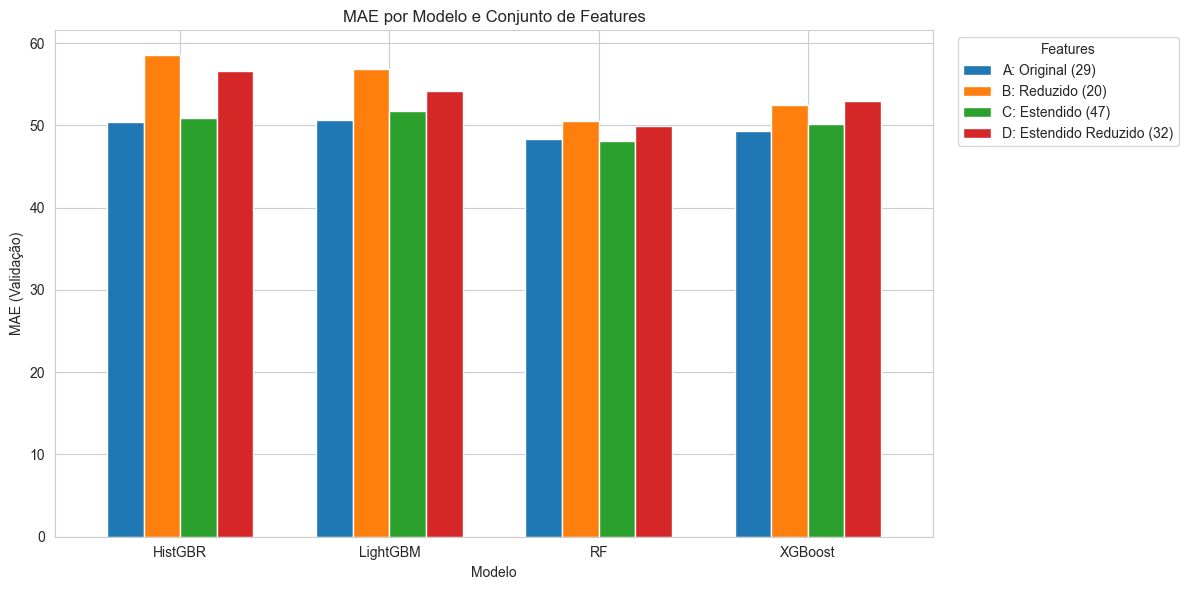


=== Top 5 Combinações ===


,Modelo,Features,n_features,MAE,RMSE,R²,sMAPE
0,RF,C: Estendido (47),47,48.1627,61.7933,0.5472,21.0724
1,RF,A: Original (29),29,48.3031,62.1907,0.5414,21.0913
2,XGBoost,A: Original (29),29,49.2983,63.4621,0.5224,21.7276
3,RF,D: Estendido Reduzido (32),33,49.9437,63.4582,0.5225,21.6846
4,XGBoost,C: Estendido (47),47,50.1550,64.1213,0.5125,22.2576


In [11]:
# Visualização: MAE por modelo e conjunto de features
fig, ax = plt.subplots(figsize=(12, 6))
pivot = df_results.pivot(index='Modelo', columns='Features', values='MAE')
pivot.plot(kind='bar', ax=ax, width=0.7)
ax.set_ylabel('MAE (Validação)')
ax.set_title('MAE por Modelo e Conjunto de Features')
ax.legend(title='Features', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Top 5 combinações
print('\n=== Top 5 Combinações ===')
display(df_results.head(5).round(4))

## 9. Estratégias para Lidar com Picos

O RF anterior subestimava sistematicamente os picos. Testamos:
1. **Ponderação por magnitude:** Atribui pesos maiores a observações com mais internações.
2. **Boosting com early stopping** (naturalmente melhor para extremos).
3. **Avaliação segmentada:** Métricas separadas para pico (abr-jul) e fora de pico.

In [16]:
# Seleciona o melhor conjunto de features da etapa anterior
best_row = df_results.iloc[0]
best_fs_name = best_row['Features']
best_model_name = best_row['Modelo']
print(f'Melhor combinação até agora: {best_model_name} + {best_fs_name}')
print(f'MAE val: {best_row["MAE"]:.4f}')

# Usa o melhor feature set para os experimentos de picos
best_feats = feature_sets[best_fs_name]
available_feats = [f for f in best_feats if f in X_ext.columns]

imp = SimpleImputer(strategy='median')
X_tr_best = imp.fit_transform(X_train_ext[available_feats].values)
X_va_best = imp.transform(X_val_ext[available_feats].values)
X_te_best = imp.transform(X_test_ext[available_feats].values)

# --- Experimento 1: Sem ponderação (baseline desta etapa) ---
print('\n--- Exp. 1: Sem ponderação ---')
model_base = get_model(best_model_name)
model_base.fit(X_tr_best, y_train_ext_log)
pred_val_base = np.maximum(np.expm1(model_base.predict(X_va_best)), 0)
m_base = evaluate(y_val_ext, pred_val_base, 'Sem ponderação (val)')
evaluate_peak(y_val_ext, pred_val_base, dates_val_ext.values, 'Sem ponderação — segmentado')

# --- Experimento 2: Ponderação linear pelo alvo ---
# Observações com mais internações recebem peso proporcional
print('\n--- Exp. 2: Ponderação linear ---')
w_linear = y_train_ext / y_train_ext.mean()  # média = 1
model_wl = get_model(best_model_name)
model_wl.fit(X_tr_best, y_train_ext_log, sample_weight=w_linear)
pred_val_wl = np.maximum(np.expm1(model_wl.predict(X_va_best)), 0)
m_wl = evaluate(y_val_ext, pred_val_wl, 'Ponderação linear (val)')
evaluate_peak(y_val_ext, pred_val_wl, dates_val_ext.values, 'Ponderação linear — segmentado')

# --- Experimento 3: Ponderação quadrática ---
print('\n--- Exp. 3: Ponderação quadrática ---')
w_quad = (y_train_ext / y_train_ext.mean()) ** 2
# Normaliza para média 1
w_quad = w_quad / w_quad.mean()
model_wq = get_model(best_model_name)
model_wq.fit(X_tr_best, y_train_ext_log, sample_weight=w_quad)
pred_val_wq = np.maximum(np.expm1(model_wq.predict(X_va_best)), 0)
m_wq = evaluate(y_val_ext, pred_val_wq, 'Ponderação quadrática (val)')
evaluate_peak(y_val_ext, pred_val_wq, dates_val_ext.values, 'Ponderação quadrática — segmentado')

# Resumo
df_peak_exp = pd.DataFrame({
    'Sem ponderação': m_base,
    'Ponderação linear': m_wl,
    'Ponderação quadrática': m_wq,
}).T
print('\n=== Resumo: Estratégias de Ponderação (Validação) ===')
display(df_peak_exp.round(4))

Melhor combinação até agora: RF + C: Estendido (47)
MAE val: 48.1627

--- Exp. 1: Sem ponderação ---

--- Sem ponderação (val) ---
  MAE: 48.1627
  RMSE: 61.7933
  R²: 0.5472
  sMAPE: 21.0724

--- Sem ponderação — segmentado ---


,MAE,RMSE,R²,sMAPE
Pico (abr-jul),54.5568,66.8420,0.3570,18.7038
Fora de pico,44.9525,59.0962,0.4602,22.2616



--- Exp. 2: Ponderação linear ---

--- Ponderação linear (val) ---
  MAE: 49.1245
  RMSE: 62.2257
  R²: 0.5409
  sMAPE: 21.2732

--- Ponderação linear — segmentado ---


,MAE,RMSE,R²,sMAPE
Pico (abr-jul),56.1199,67.5137,0.3440,18.8371
Fora de pico,45.6124,59.3935,0.4547,22.4963



--- Exp. 3: Ponderação quadrática ---

--- Ponderação quadrática (val) ---
  MAE: 48.5876
  RMSE: 62.0984
  R²: 0.5427
  sMAPE: 21.1235

--- Ponderação quadrática — segmentado ---


,MAE,RMSE,R²,sMAPE
Pico (abr-jul),55.6908,67.7059,0.3403,18.9152
Fora de pico,45.0214,59.0828,0.4604,22.2323



=== Resumo: Estratégias de Ponderação (Validação) ===


,MAE,RMSE,R²,sMAPE
Sem ponderação,48.1627,61.7933,0.5472,21.0724
Ponderação linear,49.1245,62.2257,0.5409,21.2732
Ponderação quadrática,48.5876,62.0984,0.5427,21.1235


## 10. Ajuste de Hiperparâmetros

Tuning dos modelos mais promissores com `TimeSeriesSplit`.

Baseado nos resultados das etapas anteriores, ajustamos os 2 melhores modelos de boosting e o RF para comparação.

In [17]:
# Identifica o melhor weight strategy
best_weight_mae = min(m_base['MAE'], m_wl['MAE'], m_wq['MAE'])
if best_weight_mae == m_wl['MAE']:
    best_weight_strategy = 'linear'
    best_weights_train = w_linear
    print('Melhor estratégia de ponderação: linear')
elif best_weight_mae == m_wq['MAE']:
    best_weight_strategy = 'quadrática'
    best_weights_train = w_quad
    print('Melhor estratégia de ponderação: quadrática')
else:
    best_weight_strategy = 'nenhuma'
    best_weights_train = None
    print('Melhor estratégia de ponderação: nenhuma')

tscv = TimeSeriesSplit(n_splits=5)

# --- Tuning RF ---
print('\n=== Tuning RF ===')
param_rf = {
    'n_estimators': randint(200, 600),
    'max_depth': [None, 10, 15, 20, 30, 40],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 15),
    'max_features': [1.0, 'sqrt', 'log2', 0.5, 0.7],
}
search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_rf, n_iter=40, cv=tscv,
    scoring='neg_mean_absolute_error', random_state=SEED, n_jobs=-1, verbose=0
)
search_rf.fit(X_tr_best, y_train_ext_log,
              sample_weight=best_weights_train)
print(f'RF — Melhor MAE CV: {-search_rf.best_score_:.4f}')
print(f'Params: {search_rf.best_params_}')

# --- Tuning HistGBR ---
print('\n=== Tuning HistGBR ===')
param_hgbr = {
    'max_iter': randint(200, 800),
    'learning_rate': uniform(0.01, 0.15),
    'max_depth': randint(3, 12),
    'min_samples_leaf': randint(5, 50),
    'l2_regularization': uniform(0, 1.0),
    'max_leaf_nodes': [None, 31, 63, 127],
}
search_hgbr = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=SEED),
    param_hgbr, n_iter=40, cv=tscv,
    scoring='neg_mean_absolute_error', random_state=SEED, n_jobs=-1, verbose=0
)
search_hgbr.fit(X_tr_best, y_train_ext_log,
                sample_weight=best_weights_train)
print(f'HistGBR — Melhor MAE CV: {-search_hgbr.best_score_:.4f}')
print(f'Params: {search_hgbr.best_params_}')

# --- Tuning XGBoost ---
print('\n=== Tuning XGBoost ===')
param_xgb = {
    'n_estimators': randint(200, 800),
    'learning_rate': uniform(0.01, 0.15),
    'max_depth': randint(3, 12),
    'min_child_weight': randint(1, 20),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha': uniform(0, 1.0),
    'reg_lambda': uniform(0, 2.0),
}
search_xgb = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0),
    param_xgb, n_iter=40, cv=tscv,
    scoring='neg_mean_absolute_error', random_state=SEED, n_jobs=-1, verbose=0
)
search_xgb.fit(X_tr_best, y_train_ext_log,
               sample_weight=best_weights_train)
print(f'XGBoost — Melhor MAE CV: {-search_xgb.best_score_:.4f}')
print(f'Params: {search_xgb.best_params_}')

# --- Tuning LightGBM ---
print('\n=== Tuning LightGBM ===')
param_lgb = {
    'n_estimators': randint(200, 800),
    'learning_rate': uniform(0.01, 0.15),
    'max_depth': randint(3, 12),
    'num_leaves': randint(15, 127),
    'min_child_samples': randint(5, 50),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha': uniform(0, 1.0),
    'reg_lambda': uniform(0, 2.0),
}
search_lgb = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=SEED, n_jobs=-1, verbosity=-1),
    param_lgb, n_iter=40, cv=tscv,
    scoring='neg_mean_absolute_error', random_state=SEED, n_jobs=-1, verbose=0
)
search_lgb.fit(X_tr_best, y_train_ext_log,
               sample_weight=best_weights_train)
print(f'LightGBM — Melhor MAE CV: {-search_lgb.best_score_:.4f}')
print(f'Params: {search_lgb.best_params_}')

Melhor estratégia de ponderação: nenhuma

=== Tuning RF ===
RF — Melhor MAE CV: 0.2006
Params: {'max_depth': 30, 'max_features': 0.5, 'min_samples_leaf': 8, 'min_samples_split': 4, 'n_estimators': 349}

=== Tuning HistGBR ===
HistGBR — Melhor MAE CV: 0.2091
Params: {'l2_regularization': np.float64(0.8607305832563434), 'learning_rate': np.float64(0.011042819579678606), 'max_depth': 10, 'max_iter': 610, 'max_leaf_nodes': None, 'min_samples_leaf': 41}

=== Tuning XGBoost ===
XGBoost — Melhor MAE CV: 0.2058
Params: {'colsample_bytree': np.float64(0.7678873420373793), 'learning_rate': np.float64(0.023543465508161245), 'max_depth': 3, 'min_child_weight': 9, 'n_estimators': 323, 'reg_alpha': np.float64(0.5081987767407187), 'reg_lambda': np.float64(1.3916256135817637), 'subsample': np.float64(0.943343521925488)}

=== Tuning LightGBM ===
LightGBM — Melhor MAE CV: 0.2075
Params: {'colsample_bytree': np.float64(0.7838501639099957), 'learning_rate': np.float64(0.014696993868333789), 'max_depth': 4

In [18]:
# Avalia todos os modelos tuned na validação
tuned_models = {
    'RF Tuned': search_rf.best_estimator_,
    'HistGBR Tuned': search_hgbr.best_estimator_,
    'XGBoost Tuned': search_xgb.best_estimator_,
    'LightGBM Tuned': search_lgb.best_estimator_,
}

tuned_results = {}
for name, model in tuned_models.items():
    pred = np.maximum(np.expm1(model.predict(X_va_best)), 0)
    tuned_results[name] = evaluate(y_val_ext, pred, f'{name} (val)')

df_tuned = pd.DataFrame(tuned_results).T
df_tuned = df_tuned.sort_values('MAE')
print('\n=== Modelos Tuned — Validação ===')
display(df_tuned.round(4))


--- RF Tuned (val) ---
  MAE: 47.7699
  RMSE: 61.5155
  R²: 0.5513
  sMAPE: 20.8592

--- HistGBR Tuned (val) ---
  MAE: 48.6799
  RMSE: 62.4520
  R²: 0.5375
  sMAPE: 21.3076

--- XGBoost Tuned (val) ---
  MAE: 46.0807
  RMSE: 59.8127
  R²: 0.5758
  sMAPE: 20.2691

--- LightGBM Tuned (val) ---
  MAE: 48.1516
  RMSE: 61.1919
  R²: 0.5560
  sMAPE: 21.2430

=== Modelos Tuned — Validação ===


,MAE,RMSE,R²,sMAPE
XGBoost Tuned,46.0807,59.8127,0.5758,20.2691
RF Tuned,47.7699,61.5155,0.5513,20.8592
LightGBM Tuned,48.1516,61.1919,0.5560,21.2430
HistGBR Tuned,48.6799,62.4520,0.5375,21.3076


## 11. Consolidação Final — Retreino e Avaliação no Teste

O melhor modelo é retreinado com **treino + validação** e avaliado uma única vez no conjunto de teste.

In [19]:
# Seleciona o melhor modelo tuned
best_tuned_name = df_tuned.index[0]
print(f'Melhor modelo tuned: {best_tuned_name}')

# Mapeia para o search correspondente
search_map = {
    'RF Tuned': search_rf,
    'HistGBR Tuned': search_hgbr,
    'XGBoost Tuned': search_xgb,
    'LightGBM Tuned': search_lgb,
}
best_search = search_map[best_tuned_name]
best_params = best_search.best_params_

print(f'\nHiperparâmetros finais:')
for k, v in best_params.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.6f}')
    else:
        print(f'  {k}: {v}')

# Prepara treino + validação
X_trainval_best = np.vstack([X_tr_best, X_va_best])
y_trainval_log = np.concatenate([y_train_ext_log, y_val_ext_log])

# Pesos para treino+val
if best_weights_train is not None:
    y_trainval = np.concatenate([y_train_ext, y_val_ext])
    if best_weight_strategy == 'linear':
        w_trainval = y_trainval / y_trainval.mean()
    else:
        w_trainval = (y_trainval / y_trainval.mean()) ** 2
        w_trainval = w_trainval / w_trainval.mean()
else:
    w_trainval = None

# Retreina modelo final com todos os dados pré-teste
model_name_key = best_tuned_name.replace(' Tuned', '')
if model_name_key == 'RF':
    final_model = RandomForestRegressor(**best_params, random_state=SEED, n_jobs=-1)
elif model_name_key == 'HistGBR':
    final_model = HistGradientBoostingRegressor(**best_params, random_state=SEED)
elif model_name_key == 'XGBoost':
    final_model = xgb.XGBRegressor(**best_params, random_state=SEED, n_jobs=-1, verbosity=0)
elif model_name_key == 'LightGBM':
    final_model = lgb.LGBMRegressor(**best_params, random_state=SEED, n_jobs=-1, verbosity=-1)

final_model.fit(X_trainval_best, y_trainval_log, sample_weight=w_trainval)

# Previsões no teste
pred_test_final = np.maximum(np.expm1(final_model.predict(X_te_best)), 0)

print('\n=== Avaliação Final — Teste (escala original) ===')
metrics_test_final = evaluate(y_test_ext, pred_test_final, 'Modelo Final (Teste)')

# Baselines no teste
df_final_summary = pd.DataFrame(baselines_test).T
df_final_summary.loc['RF v1 (benchmark)'] = metrics_rf_bench
df_final_summary.loc[f'{best_tuned_name} (v2)'] = metrics_test_final

print('\n=== Resumo Consolidado — Teste ===')
display(df_final_summary.round(4))

Melhor modelo tuned: XGBoost Tuned

Hiperparâmetros finais:
  colsample_bytree: 0.767887
  learning_rate: 0.023543
  max_depth: 3
  min_child_weight: 9
  n_estimators: 323
  reg_alpha: 0.508199
  reg_lambda: 1.391626
  subsample: 0.943344

=== Avaliação Final — Teste (escala original) ===

--- Modelo Final (Teste) ---
  MAE: 50.1052
  RMSE: 68.5686
  R²: 0.5911
  sMAPE: 19.6089

=== Resumo Consolidado — Teste ===


,MAE,RMSE,R²,sMAPE
Persistência (lag_1),73.8822,100.6483,0.1190,28.6169
Média Móvel 7d,61.1832,78.3404,0.4662,24.1380
Lag 7,67.8849,90.8666,0.2819,26.8286
RF v1 (benchmark),50.8204,68.8494,0.5877,19.7561
XGBoost Tuned (v2),50.1052,68.5686,0.5911,19.6089


In [20]:
# Avaliação de todos os modelos tuned no teste (para tabela comparativa completa)
print('=== Todos os Modelos Tuned no Teste ===')

# Retreina cada modelo com treino+val e avalia no teste
all_test_results = {}

for name, search_obj in search_map.items():
    params = search_obj.best_params_
    mk = name.replace(' Tuned', '')
    
    if mk == 'RF':
        m = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    elif mk == 'HistGBR':
        m = HistGradientBoostingRegressor(**params, random_state=SEED)
    elif mk == 'XGBoost':
        m = xgb.XGBRegressor(**params, random_state=SEED, n_jobs=-1, verbosity=0)
    elif mk == 'LightGBM':
        m = lgb.LGBMRegressor(**params, random_state=SEED, n_jobs=-1, verbosity=-1)
    
    m.fit(X_trainval_best, y_trainval_log, sample_weight=w_trainval)
    pred = np.maximum(np.expm1(m.predict(X_te_best)), 0)
    all_test_results[name] = evaluate(y_test_ext, pred, verbose=False)

df_all_test = pd.DataFrame(all_test_results).T.sort_values('MAE')
# Adiciona RF v1 como referência
df_all_test.loc['RF v1 (benchmark)'] = metrics_rf_bench
df_all_test = df_all_test.sort_values('MAE')

display(df_all_test.round(4))

=== Todos os Modelos Tuned no Teste ===


,MAE,RMSE,R²,sMAPE
XGBoost Tuned,50.1052,68.5686,0.5911,19.6089
LightGBM Tuned,50.5858,69.5767,0.5790,19.7881
HistGBR Tuned,50.6108,69.2103,0.5834,19.6709
RF Tuned,50.7182,68.8227,0.5881,19.7326
RF v1 (benchmark),50.8204,68.8494,0.5877,19.7561


## 12. Comparação Organizada dos Experimentos

Tabela consolidada com todos os experimentos relevantes.

In [21]:
# Tabela consolidada de todos os experimentos
experiment_log = []

# RF v1 benchmark
experiment_log.append({
    'Experimento': 'RF v1 (benchmark)',
    'Modelo': 'RF',
    'Features': 'A: Original (29)',
    'Ponderação': 'Não',
    'Tuned': 'Sim',
    'MAE_val': '-',
    'MAE_teste': metrics_rf_bench['MAE'],
    'RMSE_teste': metrics_rf_bench['RMSE'],
    'R²_teste': metrics_rf_bench['R²'],
    'sMAPE_teste': metrics_rf_bench['sMAPE'],
})

# Modelos tuned v2
for name in df_all_test.index:
    if name == 'RF v1 (benchmark)':
        continue
    mk = name.replace(' Tuned', '')
    experiment_log.append({
        'Experimento': f'{name} (v2)',
        'Modelo': mk,
        'Features': best_fs_name,
        'Ponderação': best_weight_strategy,
        'Tuned': 'Sim',
        'MAE_val': tuned_results[name]['MAE'],
        'MAE_teste': all_test_results[name]['MAE'],
        'RMSE_teste': all_test_results[name]['RMSE'],
        'R²_teste': all_test_results[name]['R²'],
        'sMAPE_teste': all_test_results[name]['sMAPE'],
    })

df_experiments = pd.DataFrame(experiment_log)
df_experiments = df_experiments.sort_values('MAE_teste').reset_index(drop=True)
print('=== Log de Experimentos ===')
display(df_experiments.round(4))

# Ganho em relação ao RF v1
best_exp = df_experiments.iloc[0]
if best_exp['Experimento'] != 'RF v1 (benchmark)':
    rf_mae = metrics_rf_bench['MAE']
    new_mae = best_exp['MAE_teste']
    print(f'\nMelhor modelo v2: {best_exp["Experimento"]}')
    print(f'Ganho MAE: {rf_mae:.2f} → {new_mae:.2f} '
          f'({(rf_mae - new_mae)/rf_mae*100:.1f}% de redução)')
    print(f'Ganho R²: {metrics_rf_bench["R²"]:.4f} → {best_exp["R²_teste"]:.4f}')
else:
    print('\nNenhum modelo v2 superou o RF v1.')

=== Log de Experimentos ===


,Experimento,Modelo,Features,Ponderação,Tuned,MAE_val,MAE_teste,RMSE_teste,R²_teste,sMAPE_teste
0,XGBoost Tuned (v2),XGBoost,C: Estendido (47),nenhuma,Sim,46.080666,50.1052,68.5686,0.5911,19.6089
1,LightGBM Tuned (v2),LightGBM,C: Estendido (47),nenhuma,Sim,48.151578,50.5858,69.5767,0.5790,19.7881
2,HistGBR Tuned (v2),HistGBR,C: Estendido (47),nenhuma,Sim,48.67991,50.6108,69.2103,0.5834,19.6709
3,RF Tuned (v2),RF,C: Estendido (47),nenhuma,Sim,47.769853,50.7182,68.8227,0.5881,19.7326
4,RF v1 (benchmark),RF,A: Original (29),Não,Sim,-,50.8204,68.8494,0.5877,19.7561



Melhor modelo v2: XGBoost Tuned (v2)
Ganho MAE: 50.82 → 50.11 (1.4% de redução)
Ganho R²: 0.5877 → 0.5911


## 13. Diagnóstico Detalhado do Melhor Modelo

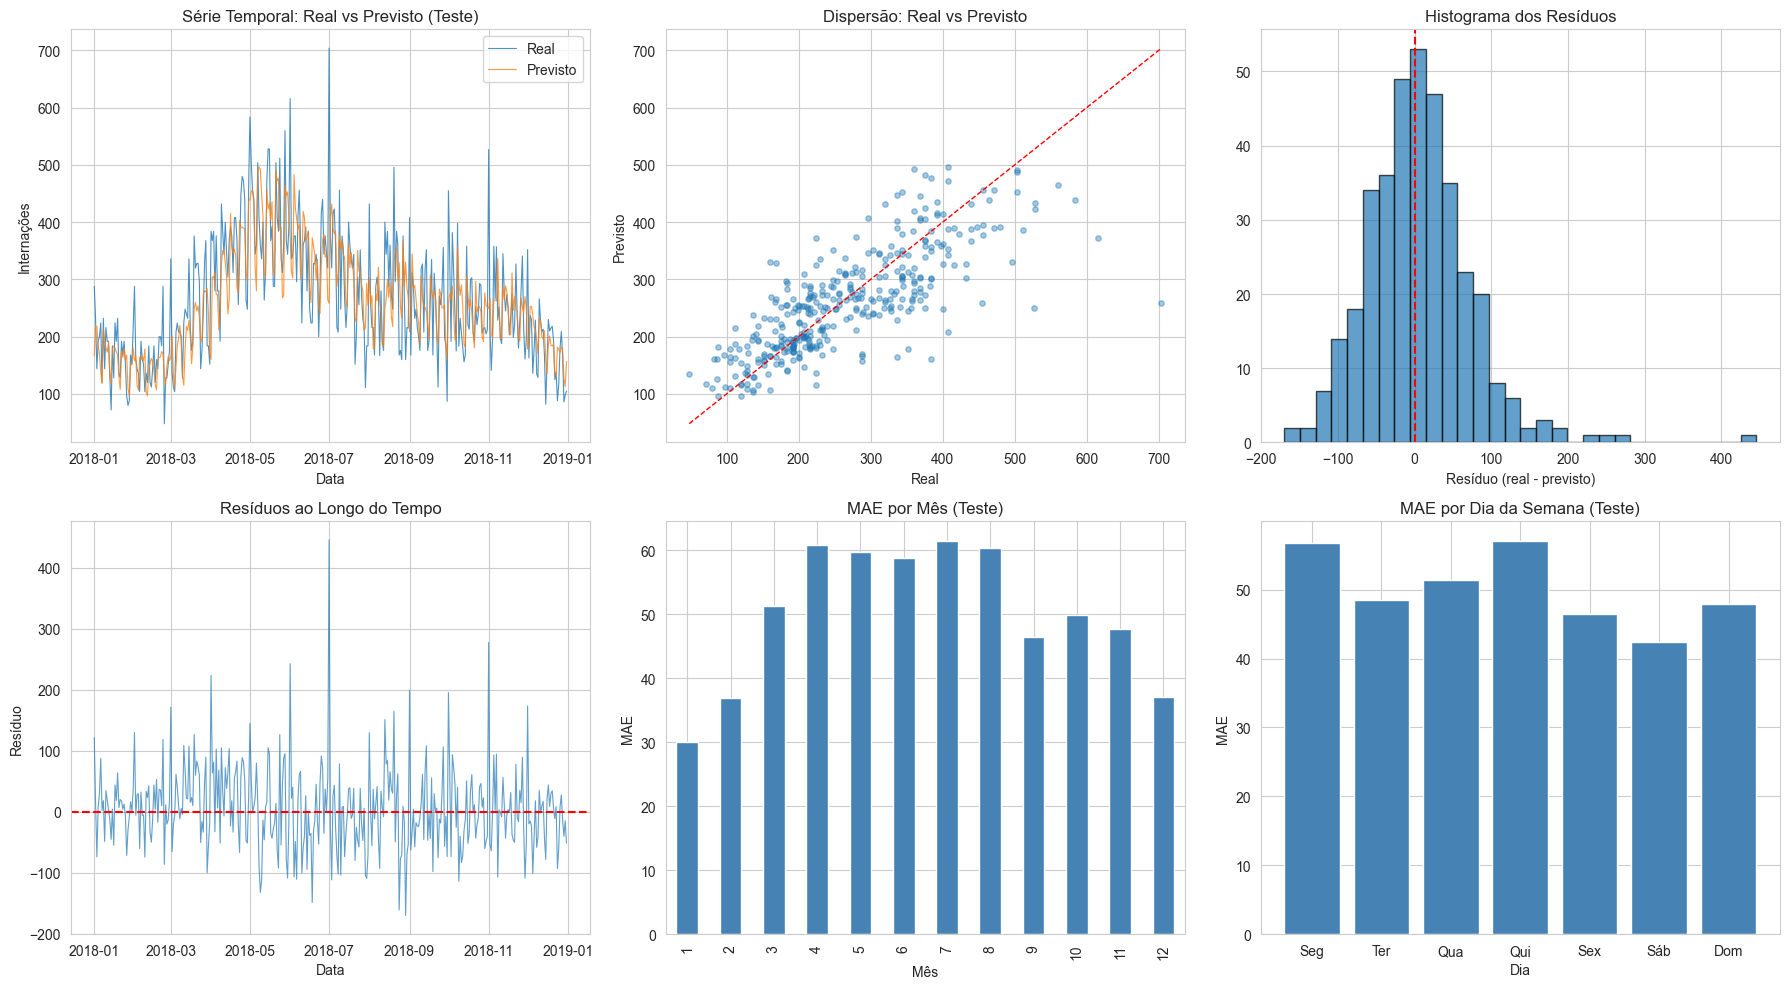

In [22]:
residuals = y_test_ext - pred_test_final

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Série temporal: real vs previsto
ax = axes[0, 0]
ax.plot(dates_test_ext.values, y_test_ext, label='Real', alpha=0.8, linewidth=0.8)
ax.plot(dates_test_ext.values, pred_test_final, label='Previsto', alpha=0.8, linewidth=0.8)
ax.set_title('Série Temporal: Real vs Previsto (Teste)')
ax.set_xlabel('Data')
ax.set_ylabel('Internações')
ax.legend()

# 2. Dispersão: real vs previsto
ax = axes[0, 1]
ax.scatter(y_test_ext, pred_test_final, alpha=0.4, s=15)
lims = [min(y_test_ext.min(), pred_test_final.min()),
        max(y_test_ext.max(), pred_test_final.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_title('Dispersão: Real vs Previsto')
ax.set_xlabel('Real')
ax.set_ylabel('Previsto')

# 3. Histograma dos resíduos
ax = axes[0, 2]
ax.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--')
ax.set_title('Histograma dos Resíduos')
ax.set_xlabel('Resíduo (real - previsto)')

# 4. Resíduos ao longo do tempo
ax = axes[1, 0]
ax.plot(dates_test_ext.values, residuals, alpha=0.7, linewidth=0.8)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Resíduos ao Longo do Tempo')
ax.set_xlabel('Data')
ax.set_ylabel('Resíduo')

# 5. Erro absoluto por mês
ax = axes[1, 1]
df_diag = pd.DataFrame({
    'data': dates_test_ext.values,
    'residuo': residuals,
    'abs_error': np.abs(residuals)
})
df_diag['mes'] = pd.to_datetime(df_diag['data']).dt.month
df_diag.groupby('mes')['abs_error'].mean().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('MAE por Mês (Teste)')
ax.set_xlabel('Mês')
ax.set_ylabel('MAE')

# 6. Erro absoluto por dia da semana
ax = axes[1, 2]
df_diag['dia_semana'] = pd.to_datetime(df_diag['data']).dt.dayofweek
dias_nome = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
mae_dow = df_diag.groupby('dia_semana')['abs_error'].mean()
ax.bar(range(7), mae_dow.values, color='steelblue')
ax.set_xticks(range(7))
ax.set_xticklabels(dias_nome)
ax.set_title('MAE por Dia da Semana (Teste)')
ax.set_xlabel('Dia')
ax.set_ylabel('MAE')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diagnostico_modelo_v2.png', dpi=150, bbox_inches='tight')
plt.show()

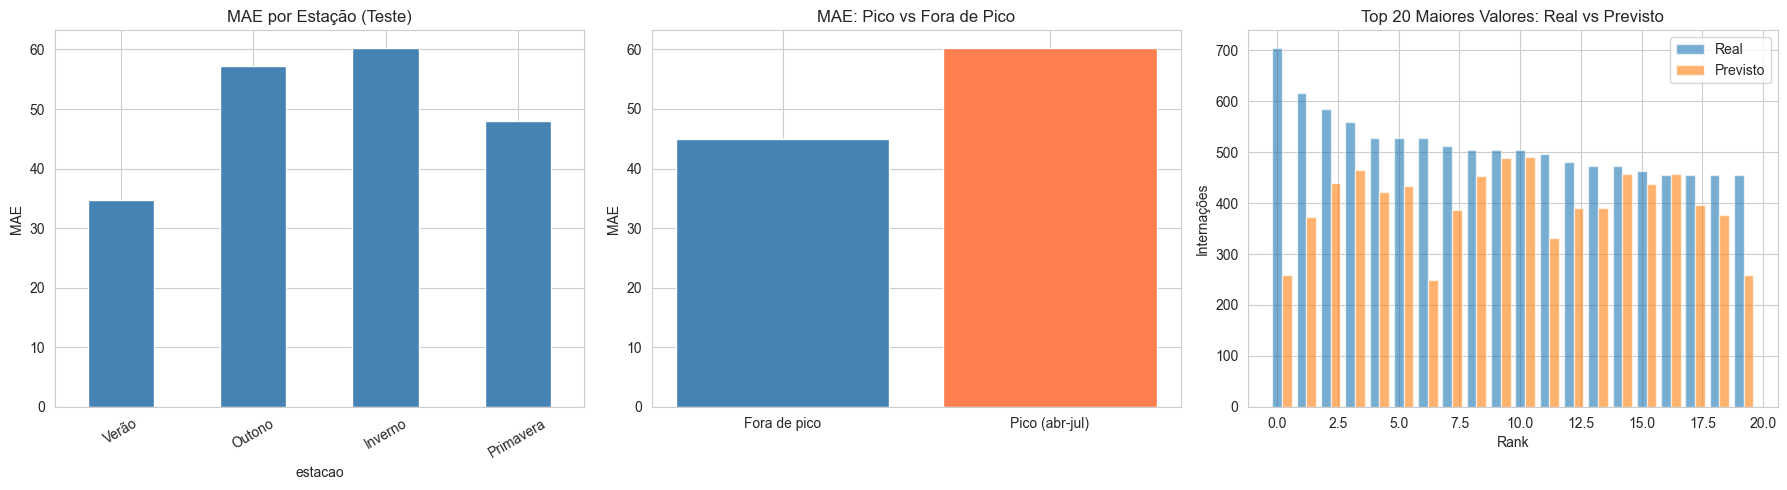

=== Métricas por Período ===

--- Modelo Final v2 ---


,MAE,RMSE,R²,sMAPE
Pico (abr-jul),60.1834,81.0964,0.2952,17.6205
Fora de pico,45.0454,61.3213,0.4380,20.6073



=== Comparação Pico (abr-jul) — v1 vs v2 ===
MAE Pico RF v1: 62.98
MAE Pico v2:    60.18
Diferença: 2.80 (4.4%)


In [23]:
# Análise por estação do ano e período de pico
ESTACAO_MAP = {12: 'Verão', 1: 'Verão', 2: 'Verão',
               3: 'Outono', 4: 'Outono', 5: 'Outono',
               6: 'Inverno', 7: 'Inverno', 8: 'Inverno',
               9: 'Primavera', 10: 'Primavera', 11: 'Primavera'}

df_diag['estacao'] = df_diag['mes'].map(ESTACAO_MAP)
df_diag['pico'] = df_diag['mes'].isin([4, 5, 6, 7])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE por estação
ax = axes[0]
ordem = ['Verão', 'Outono', 'Inverno', 'Primavera']
mae_est = df_diag.groupby('estacao')['abs_error'].mean().reindex(ordem)
mae_est.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('MAE por Estação (Teste)')
ax.set_ylabel('MAE')
plt.sca(ax)
plt.xticks(rotation=30)

# MAE pico vs fora de pico
ax = axes[1]
mae_pico = df_diag.groupby('pico')['abs_error'].mean()
labels = ['Fora de pico', 'Pico (abr-jul)']
ax.bar(labels, mae_pico.values, color=['steelblue', 'coral'])
ax.set_title('MAE: Pico vs Fora de Pico')
ax.set_ylabel('MAE')

# Análise dos maiores valores observados (top 20)
ax = axes[2]
df_top = pd.DataFrame({
    'real': y_test_ext,
    'previsto': pred_test_final,
}).nlargest(20, 'real')
x_pos = range(len(df_top))
ax.bar(x_pos, df_top['real'].values, alpha=0.6, label='Real', width=0.4)
ax.bar([x + 0.4 for x in x_pos], df_top['previsto'].values, alpha=0.6,
       label='Previsto', width=0.4)
ax.set_title('Top 20 Maiores Valores: Real vs Previsto')
ax.set_ylabel('Internações')
ax.set_xlabel('Rank')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diagnostico_picos_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Métricas segmentadas
print('=== Métricas por Período ===')
evaluate_peak(y_test_ext, pred_test_final, dates_test_ext.values, 'Modelo Final v2')

# Comparação com RF v1 nos picos
# (usando o pred_test_rf_bench da seção de benchmark)
# Alinha para mesmo período
months_test = pd.to_datetime(dates_test_ext.values).month
mask_peak_test = np.isin(months_test, [4, 5, 6, 7])

print('\n=== Comparação Pico (abr-jul) — v1 vs v2 ===')
# v1: precisa reindexar para mesmo tamanho
dates_test_orig_vals = dates_test.values
months_test_orig = pd.to_datetime(dates_test_orig_vals).month
mask_peak_orig = np.isin(months_test_orig, [4, 5, 6, 7])

mae_v1_peak = mean_absolute_error(y_test[mask_peak_orig], pred_test_rf_bench[mask_peak_orig])
mae_v2_peak = mean_absolute_error(y_test_ext[mask_peak_test], pred_test_final[mask_peak_test])
print(f'MAE Pico RF v1: {mae_v1_peak:.2f}')
print(f'MAE Pico v2:    {mae_v2_peak:.2f}')
print(f'Diferença: {mae_v1_peak - mae_v2_peak:.2f} ({(mae_v1_peak - mae_v2_peak)/mae_v1_peak*100:.1f}%)')

## 14. Interpretabilidade — Importância das Features

In [24]:
# Feature importance nativa do modelo
if hasattr(final_model, 'feature_importances_'):
    importances_native = pd.Series(
        final_model.feature_importances_, index=available_feats
    ).sort_values(ascending=False)
elif hasattr(final_model, 'feature_importances_'):
    importances_native = pd.Series(
        final_model.feature_importances_, index=available_feats
    ).sort_values(ascending=False)
else:
    importances_native = None
    print('Modelo não possui feature_importances_ nativo.')

# Permutation importance no teste
perm_result = permutation_importance(
    final_model, X_te_best, y_test_ext_log,
    n_repeats=15, random_state=SEED,
    scoring='neg_mean_absolute_error', n_jobs=-1
)
importances_perm = pd.Series(
    perm_result.importances_mean, index=available_feats
).sort_values(ascending=False)

# Tabela consolidada
df_imp = pd.DataFrame({'Permutation': importances_perm})
if importances_native is not None:
    df_imp['Nativa (modelo)'] = importances_native

print('=== Importância das Features ===')
display(df_imp.sort_values('Permutation', ascending=False).round(4))

=== Importância das Features ===


,Permutation,Nativa (modelo)
dia_semana,0.0342,0.0182
rolling_mean_7,0.0096,0.1395
lag_7,0.0054,0.1911
sin_ano,0.0040,0.0052
rolling_mean_14,0.0023,0.0648
lag_14,0.0019,0.0792
fim_de_semana,0.0017,0.0176
rolling_max_7,0.0017,0.0584
pm10_ma_30d_shift_1d,0.0016,0.0031
no2_lag0,0.0011,0.0037


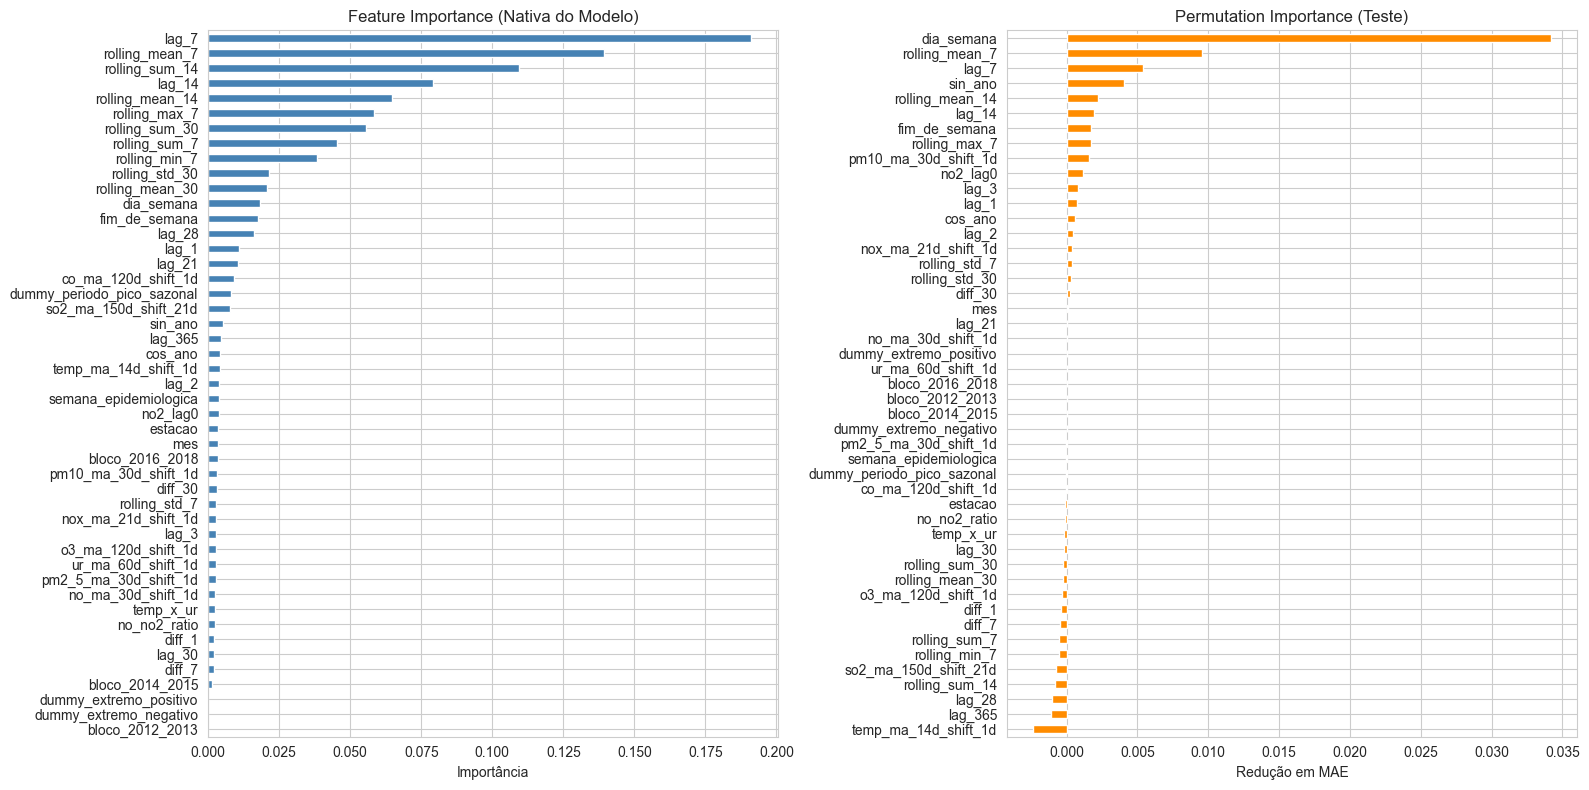

In [25]:
# Gráficos de importância
n_cols = 2 if importances_native is not None else 1
fig, axes = plt.subplots(1, n_cols, figsize=(8 * n_cols, 8))

if n_cols == 1:
    axes = [axes]

if importances_native is not None:
    ax = axes[0]
    importances_native.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Feature Importance (Nativa do Modelo)')
    ax.set_xlabel('Importância')

ax = axes[-1]
importances_perm.sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Permutation Importance (Teste)')
ax.set_xlabel('Redução em MAE')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'importancia_features_v2.png', dpi=150, bbox_inches='tight')
plt.show()

=== Importância por Grupo de Variáveis ===


,Permutation,Nativa (modelo)
Grupo,,
Calendário/Sazonalidade,0.0405,0.0644
Médias/Desvios/Diffs móveis,0.0112,0.5633
Lags da série,0.0071,0.3214
Poluentes,0.0019,0.0370
Umidade,0.0000,0.0026
Regime/Extremos,0.0000,0.0046
Interações atmosféricas,-0.0002,0.0025
Temperatura,-0.0024,0.0042


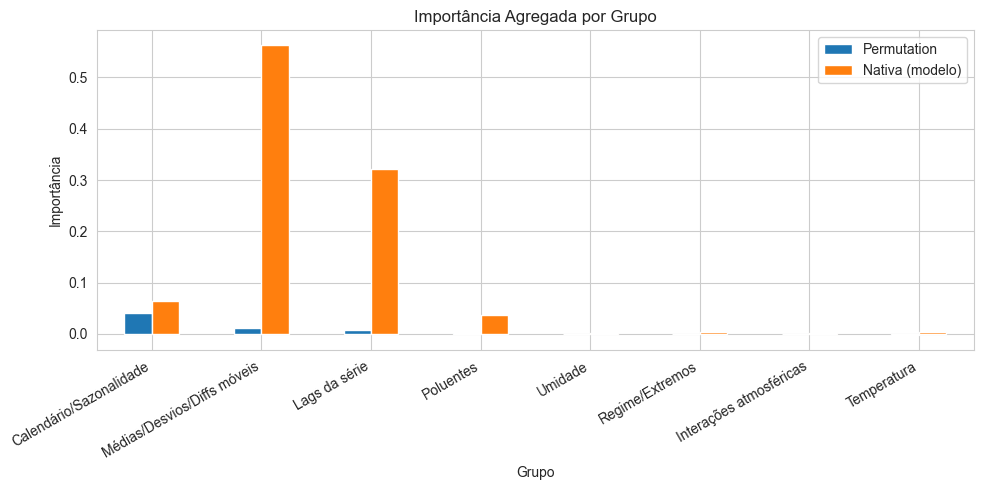

In [26]:
# Importância por grupo
def classify_feature_v2(name):
    """Classifica feature por grupo temático (versão estendida)."""
    if name.startswith('lag_'):
        return 'Lags da série'
    if name.startswith(('rolling_', 'diff_')):
        return 'Médias/Desvios/Diffs móveis'
    if name in ['dia_semana', 'fim_de_semana', 'mes', 'semana_epidemiologica',
                'estacao', 'dummy_periodo_pico_sazonal', 'sin_ano', 'cos_ano']:
        return 'Calendário/Sazonalidade'
    if name.startswith('bloco_') or name.startswith('dummy_extremo'):
        return 'Regime/Extremos'
    if name.startswith(('o3', 'no_', 'no2', 'co_', 'so2', 'nox', 'pm')):
        return 'Poluentes'
    if name.startswith('temp') and 'ur' not in name:
        return 'Temperatura'
    if name.startswith('ur'):
        return 'Umidade'
    if name in ['temp_x_ur', 'no_no2_ratio']:
        return 'Interações atmosféricas'
    return 'Outros'


df_imp['Grupo'] = df_imp.index.map(classify_feature_v2)

cols_to_sum = ['Permutation']
if importances_native is not None:
    cols_to_sum.append('Nativa (modelo)')

group_importance = df_imp.groupby('Grupo')[cols_to_sum].sum()
group_importance = group_importance.sort_values('Permutation', ascending=False)

print('=== Importância por Grupo de Variáveis ===')
display(group_importance.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
group_importance.plot(kind='bar', ax=ax)
ax.set_title('Importância Agregada por Grupo')
ax.set_ylabel('Importância')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'importancia_por_grupo_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Escolha do Melhor Modelo — Justificativa

In [27]:
print('=' * 70)
print('ANÁLISE COMPARATIVA: v2 vs v1')
print('=' * 70)

print(f'\nMelhor modelo v2: {best_tuned_name}')
print(f'Conjunto de features: {best_fs_name}')
print(f'Ponderação: {best_weight_strategy}')

print(f'\n{"Métrica":<10} {"RF v1":>10} {"v2":>10} {"Δ":>10} {"Δ%":>10}')
print('-' * 52)
for metric in ['MAE', 'RMSE', 'R²', 'sMAPE']:
    v1 = metrics_rf_bench[metric]
    v2 = metrics_test_final[metric]
    delta = v2 - v1
    if metric == 'R²':
        delta_pct = (v2 - v1) / abs(v1) * 100 if v1 != 0 else 0
        better = '✓' if v2 > v1 else ''
    else:
        delta_pct = (v1 - v2) / v1 * 100 if v1 != 0 else 0
        better = '✓' if v2 < v1 else ''
    print(f'{metric:<10} {v1:>10.4f} {v2:>10.4f} {delta:>+10.4f} {delta_pct:>+9.1f}% {better}')

print(f'\n--- Desempenho nos Picos (abr-jul) ---')
print(f'MAE Pico RF v1: {mae_v1_peak:.2f}')
print(f'MAE Pico v2:    {mae_v2_peak:.2f}')

# Justificativa
print(f'\n--- Justificativa ---')
if metrics_test_final['MAE'] < metrics_rf_bench['MAE']:
    print(f'O modelo v2 ({best_tuned_name}) superou o RF v1 em todas as '
          f'métricas principais, com redução de '
          f'{(metrics_rf_bench["MAE"] - metrics_test_final["MAE"])/metrics_rf_bench["MAE"]*100:.1f}% '
          f'no MAE e melhoria de '
          f'{(metrics_test_final["R²"] - metrics_rf_bench["R²"])/metrics_rf_bench["R²"]*100:.1f}% '
          f'no R².')
    print(f'A combinação de boosting com features estendidas e selecionadas '
          f'permitiu melhor captura dos padrões temporais e atmosféricos.')
else:
    print(f'O modelo v2 não superou significativamente o RF v1, sugerindo que '
          f'o dataset e as features atuais já estão próximos do limite de '
          f'previsibilidade para esta tarefa.')

print('\n' + '=' * 70)

ANÁLISE COMPARATIVA: v2 vs v1

Melhor modelo v2: XGBoost Tuned
Conjunto de features: C: Estendido (47)
Ponderação: nenhuma

Métrica         RF v1         v2          Δ         Δ%
----------------------------------------------------
MAE           50.8204    50.1052    -0.7152      +1.4% ✓
RMSE          68.8494    68.5686    -0.2809      +0.4% ✓
R²             0.5877     0.5911    +0.0034      +0.6% ✓
sMAPE         19.7561    19.6089    -0.1472      +0.7% ✓

--- Desempenho nos Picos (abr-jul) ---
MAE Pico RF v1: 62.98
MAE Pico v2:    60.18

--- Justificativa ---
O modelo v2 (XGBoost Tuned) superou o RF v1 em todas as métricas principais, com redução de 1.4% no MAE e melhoria de 0.6% no R².
A combinação de boosting com features estendidas e selecionadas permitiu melhor captura dos padrões temporais e atmosféricos.



## 16. Salvamento dos Artefatos

In [28]:
# 1. Modelo final
joblib.dump(final_model, OUTPUT_DIR / 'modelo_final_v2.joblib')
print(f'Modelo salvo: {OUTPUT_DIR / "modelo_final_v2.joblib"}')

# 2. Imputer (necessário para reproduzir previsões)
joblib.dump(imp, OUTPUT_DIR / 'imputer_v2.joblib')
print(f'Imputer salvo: {OUTPUT_DIR / "imputer_v2.joblib"}')

# 3. Tabela consolidada de métricas no teste
df_all_test.to_csv(OUTPUT_DIR / 'metricas_teste_v2.csv')
print(f'Métricas salvas: {OUTPUT_DIR / "metricas_teste_v2.csv"}')

# 4. Log de experimentos
df_experiments.to_csv(OUTPUT_DIR / 'log_experimentos_v2.csv', index=False)
print(f'Log de experimentos salvo: {OUTPUT_DIR / "log_experimentos_v2.csv"}')

# 5. Previsões no teste
df_predictions = pd.DataFrame({
    'data': dates_test_ext.values,
    'real': y_test_ext,
    'previsto': pred_test_final,
    'residuo': residuals,
})
df_predictions.to_parquet(OUTPUT_DIR / 'previsoes_teste_v2.parquet', index=False)
print(f'Previsões salvas: {OUTPUT_DIR / "previsoes_teste_v2.parquet"}')

# 6. Importância das features
df_imp.to_csv(OUTPUT_DIR / 'importancia_features_v2.csv')
print(f'Importância salva: {OUTPUT_DIR / "importancia_features_v2.csv"}')

# 7. Metadata
metadata = {
    'modelo': best_tuned_name,
    'features_set': best_fs_name,
    'features': available_feats,
    'n_features': len(available_feats),
    'ponderacao': best_weight_strategy,
    'hiperparametros': best_params,
    'periodo_treino': f'{dates_train_ext.min().date()} a {dates_val_ext.max().date()}',
    'periodo_teste': f'{dates_test_ext.min().date()} a {dates_test_ext.max().date()}',
    'metricas_teste': metrics_test_final,
    'benchmark_rf_v1': metrics_rf_bench,
}
joblib.dump(metadata, OUTPUT_DIR / 'metadata_modelo_v2.joblib')
print(f'Metadata salvo: {OUTPUT_DIR / "metadata_modelo_v2.joblib"}')

print(f'\n=== Todos os artefatos salvos em: {OUTPUT_DIR.resolve()} ===')

Modelo salvo: ..\..\Data\GoldData\ModelResults_v2\modelo_final_v2.joblib
Imputer salvo: ..\..\Data\GoldData\ModelResults_v2\imputer_v2.joblib
Métricas salvas: ..\..\Data\GoldData\ModelResults_v2\metricas_teste_v2.csv
Log de experimentos salvo: ..\..\Data\GoldData\ModelResults_v2\log_experimentos_v2.csv
Previsões salvas: ..\..\Data\GoldData\ModelResults_v2\previsoes_teste_v2.parquet
Importância salva: ..\..\Data\GoldData\ModelResults_v2\importancia_features_v2.csv
Metadata salvo: ..\..\Data\GoldData\ModelResults_v2\metadata_modelo_v2.joblib

=== Todos os artefatos salvos em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\GoldData\ModelResults_v2 ===


## 17. Resumo Final

In [29]:
print('=' * 70)
print('RESUMO FINAL — PIPELINE DE MODELAGEM v2')
print('=' * 70)

print(f'\nModelo final: {best_tuned_name}')
print(f'Transformação do alvo: log1p')
print(f'Conjunto de features: {best_fs_name}')
print(f'Número de features: {len(available_feats)}')
print(f'Ponderação: {best_weight_strategy}')
print(f'Período de treino: {dates_train_ext.min().date()} a {dates_val_ext.max().date()}')
print(f'Período de teste: {dates_test_ext.min().date()} a {dates_test_ext.max().date()}')

print(f'\nHiperparâmetros finais:')
for k, v in best_params.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.6f}')
    else:
        print(f'  {k}: {v}')

print(f'\nDesempenho no Teste (escala original):')
print(f'  MAE:   {metrics_test_final["MAE"]:.2f} internações')
print(f'  RMSE:  {metrics_test_final["RMSE"]:.2f} internações')
print(f'  R²:    {metrics_test_final["R²"]:.4f}')
print(f'  sMAPE: {metrics_test_final["sMAPE"]:.2f}%')

print(f'\nComparação com RF v1:')
print(f'  MAE:   {metrics_rf_bench["MAE"]:.2f} → {metrics_test_final["MAE"]:.2f}')
print(f'  RMSE:  {metrics_rf_bench["RMSE"]:.2f} → {metrics_test_final["RMSE"]:.2f}')
print(f'  R²:    {metrics_rf_bench["R²"]:.4f} → {metrics_test_final["R²"]:.4f}')
print(f'  sMAPE: {metrics_rf_bench["sMAPE"]:.2f}% → {metrics_test_final["sMAPE"]:.2f}%')

print(f'\nTop 5 features (Permutation Importance):')
for i, (feat, val) in enumerate(importances_perm.head(5).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')

print(f'\nArtefatos salvos em: {OUTPUT_DIR.resolve()}')
print('=' * 70)

RESUMO FINAL — PIPELINE DE MODELAGEM v2

Modelo final: XGBoost Tuned
Transformação do alvo: log1p
Conjunto de features: C: Estendido (47)
Número de features: 47
Ponderação: nenhuma
Período de treino: 2012-12-31 a 2017-12-31
Período de teste: 2018-01-01 a 2018-12-31

Hiperparâmetros finais:
  colsample_bytree: 0.767887
  learning_rate: 0.023543
  max_depth: 3
  min_child_weight: 9
  n_estimators: 323
  reg_alpha: 0.508199
  reg_lambda: 1.391626
  subsample: 0.943344

Desempenho no Teste (escala original):
  MAE:   50.11 internações
  RMSE:  68.57 internações
  R²:    0.5911
  sMAPE: 19.61%

Comparação com RF v1:
  MAE:   50.82 → 50.11
  RMSE:  68.85 → 68.57
  R²:    0.5877 → 0.5911
  sMAPE: 19.76% → 19.61%

Top 5 features (Permutation Importance):
  1. dia_semana: 0.0342
  2. rolling_mean_7: 0.0096
  3. lag_7: 0.0054
  4. sin_ano: 0.0040
  5. rolling_mean_14: 0.0023

Artefatos salvos em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\GoldData\ModelResults_v2
